# Filtro de Bayes Recursivo

Esta atividade apresenta o Teorema de Bayes e como ele pode ser utilizado para realizar uma estimativa.

## Onde está a codorna? 🐦

Uma codorna pia no meio da mata. Um ninja escuta. A codorna pia mais uma vez. O ninja escuta novamente. O ninja quer saber onde está a codorna. A codorna pia novamente. E ela faz isso mais 100 vezes.

__Pergunta:__ Será o ninja capaz de descobrir a posição da codorna no meio da mata?

Continua...

## Conceitos Iniciais

__Palavras-chave:__

* Hipótese: uma pergunta - uma Teoria seria uma afirmação?;
* Dado: uma informação, uma observação;
* Verossimilhança: ou _likelihood_, o grau de veracidade de uma determinada informação;
* _Prior_: aquilo que se conhece a princípio (informação _a priori_);
* _Posterior_: aquilo que se conclui (informação _a posteriori_);

__Conceito-chave:__ 

* Probabilidade condicional: a ocorrência de um evento dada uma informação _a priori_.

## Teorema de Bayes

O Teorema de Bayes é dado pela seguinte equação:

\begin{align}
p(h|d) = \frac{p(d|h)p(h)}{p(d)}
\end{align}

onde:

* $h$: hipótese;
* $d$: "dado" (uma informação);
* $p(h|d)$: é o __posterior__ (ou a hipótese a ser "testada" dada uma determinada informação, a posteriori);
* $p(h)$: é a probabilidade do dado (ou da informação ocorrer);
* $p(d|h)$: é o __prior__ (a informação inicial). É também a __verossimilhança__ da informação dada a hipótese (ou _likelihood_).

__Pergunta:__ O que significa "máxima verossimilhança"?

## Probabilidade X Verossimilhança

Probabilidade é a chance de ocorrência de um determinado evento possível. Verossimilhança é o quão provável (ou possível) que este evento exista. Este evento é plausível?

Para que um determinado evento ocorra, é necessário que ele exista e que pertença a um determinado conjunto de eventos possíveis. Portanto, a máxima verossimilhança destaca o quão verossímil é a probabilidade do evento.

__Exemplo de Verossimilhança:__

Considere que a observação do lançamento de 20 dados sobre uma mesa e que todos os dados apresentam os mesmos valores. Deseja-se saber qual é a verossimilhança desta observação.

Para isto, consideramos duas hipótese:

1. __Dados são viciados:__ neste caso, os 20 dados apresentam o mesmo valor (5, por exemplo). A probabilidade conjunta destes eventos é $p(\text{dado1}) \times p(\text{dado2}) \times p(\text{dado3}) \times \dots \times p(\text{dado20}) = \left(\frac{1}{1}\right)^{20} = 1$;
2. __Dados não são viciados:__ neste caso, cada um dos 20 dados possui a mesma probabilidade de apresentar um dos 6 números possíveis. A probabilidade conjunta destes eventos é $\left(\frac{1}{6}\right)^{20} \approx 0$.

Portanto, é muito mais verossímil que o dado seja viciado dada a observação inicial (todos os dados apresentam o mesmo número).

## E a Codorna?

Sejam,

* $d$: o ninja ouve um canto na mata;
* $h$: há uma codorna na mata.

Observe que:

\begin{align}
p(d|h) \ne p(h|d)
\end{align}

* $p(d|h)$ é alta: se há uma codorna na mata, então há um canto ecoando na mata;
* $p(h|d)$ é baixa: se há uma codorna na mata, não necessariamente ela está cantando e o que o ninja ouve não é uma codorna, mas sim um pardal.

Continua...

## Estimativa de Máxima Verossimilhança

* Permite estimar, por exemplo, os momentos estatísticos (eg., média, desvio-padrão e variância) de uma determinada distribuição. Por exemplo:
    - Quais são os valores de média e variância que maximizam a probabilidade de um determinado evento (ou hipótese) ou dado observado?
    
__Exemplo de Inferência Bayesiana (ou Filtro Bayesiano):__

* Kalnay, 2002: Dadas suas observações independentes $T_1$ e $T_2$, as quais são assumidas possuirem distribuição normal e erros com desvio-padrão $\sigma_1$ e $\sigma_2$, qual é o valor mais provável de $T$ dadas as observações e as suas estatísticas de erro?

\begin{align}
p(T|T_{1},T_{2}) = \frac{p(T_{1},T_{2}|T)p(T)}{p(T_{1},T_{2})}
\end{align}

## Distribuição Normal (ou Gaussiana)

É a distribuição estatística mais conhecida. No contexto do nosso problema, ela pode ser enunciada por:

\begin{align}
p_{\sigma_{1}}(T_{1}|T) = \frac{1}{\sigma_{1}\sqrt{2\pi}}e^{-\frac{(T_{1}-T)^{2}}{2\sigma_{1}^{2}}}
\end{align}

e

\begin{align}
p_{\sigma_{2}}(T_{2}|T) = \frac{1}{\sigma_{2}\sqrt{2\pi}}e^{-\frac{(T_{2}-T)^{2}}{2\sigma_{2}^{2}}}
\end{align}

onde:

* $\sigma_{1}$: é o desvio-padrão da observação $T_1$;
* $\sigma_{2}$: é o desvio-padrão da observação $T_2$.

O valor mais provável (_likelly_) de $T$, dadas as observações independentes $T_1$ e $T_2$, é aquela que maximiza a __probabilidade conjunta__, ou seja, o produto de $p_{\sigma_{1}}$ e $p_{\sigma_{2}}$.

Observe que $p_{\sigma}$ é a probabilidade considerando o desvio-padrão da observação!

## Mas onde está a codorna?

__Filtro de Bayes Recursivo__

* Um ninja ouve o canto intermitente de uma codorna (ela está parada). A cada canto, ele tenta descobrir a posição da codorna. Como o ninja pode inferir a posição da codorna?
* Brincadeira do "quente-frio"?
* Um outro problema real poderia ser: Um modelo tenta se ajustar aos valores observados a cada ciclo de análise (iterativamente!). Como isso pode ser feito?

🥷 🐦

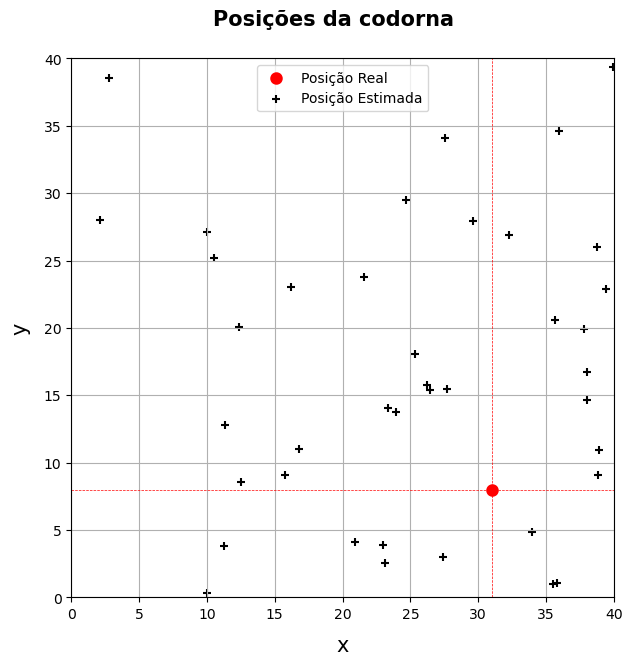

In [1]:
"""
Written by StudentDave
for licensing and usage questions
email scienceguy5000 at gmail. com

Recursive Bayesian Estimation example:
adapted from Michael A. Goodrich
3 Sept 2004, CS 470
Original in http://students.cs.byu.edu/~cs470ta/goodrich/fall2005/MATLAB/BayesEstimator.html

Exemplo de Inferência Bayesiana Recursiva:
Adaptado de Michael A. Goodrich por Carlos Frederico Bastarz
1 Julho 2013, CPTEC
Versão em Python por Carlos Frederico Bastarz
18 Julho 2019, CPTEC
"""

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import axes3d
from IPython.display import clear_output
import time

# N é um parâmetro que iremos utilizar para determinar o número que vezes
# que o ninja ouve o canto da codorna
N = 100

# Posição cartesiana (x,y) verdadeira da codorna 
# (esta é a posição que o ninja deve inferir)
s = [[31],[8]]
s = np.asarray(s)

# A codorna canta N vezes e, para cada canto, o ninja ouve a codorna em
# algum local. O erro na estimativa de onde esta a codorna e definido como
# uma Gaussiana ao redor da posicao real da codorna, com um desvio padrao
# arbitrário "std":

# Vetor de cantos iterativos com desvio padrao arbitrário "std"
std = 20
n = std * np.random.randn(2,N)

# x será a variável inicializada para onde o ninja acredita 
# que a codorna esteja posicionada
x = np.zeros((2,N)) 

# Centraliza a Gaussiana ao redor do ponto em que a codorna realmente está e plota:
fig = plt.figure(figsize=(7,7))
fig.suptitle("Posições da codorna", fontweight="bold", size=15, y=0.95)

ax = fig.add_subplot(1, 1, 1)
ax.scatter(s[0], s[1], color="red", marker="o", linewidth=3, label="Posição Real")
ax.axhline(s[1], color="red", linewidth=0.5, ls="dashed")
ax.axvline(s[0], color="red", linewidth=0.5, ls="dashed")

# Plota as posições em que o ninja acredita onde a codorna esteja:
x = s + n
ax.scatter(x[0], x[1], marker="+", color="black", linewidth=1.5, label="Posição Estimada")
plt.xlim(0,40)
plt.ylim(0,40)
ax.legend()
ax.grid(True)
ax.set_xlabel("x", labelpad=10, size="15")
ax.set_ylabel("y", labelpad=10, size="15")

plt.show()

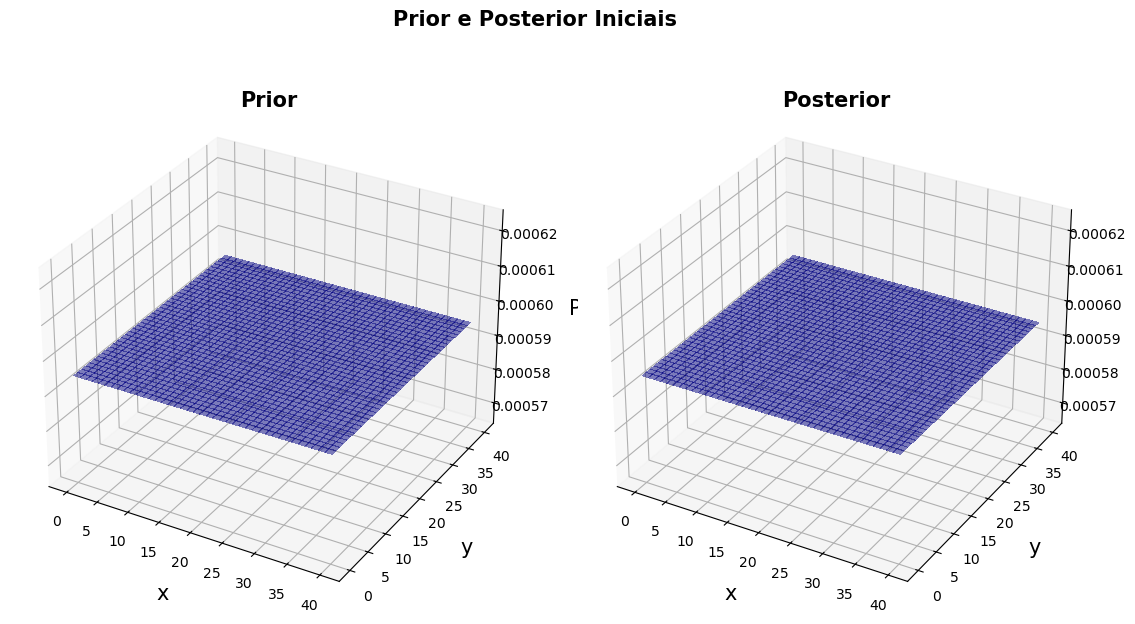

In [2]:
# Agora, o ninja aplica o Teorema de Bayes para inferir a posição mais provável da codorna

# Define limites em a e b (em x e y, mais precisamente) para as posições em
# que a codorna pode estar. Estes limites devem estar ao redor da posição real da codorna
#Sa = np.arange(30, 32.05, 0.05)
#Sb = np.arange(14, 16.05, 0.05)
Sa = np.arange(0, 41, 1)
Sb = np.arange(0, 41, 1)

# L é o tamanho da dimensão Sa (ou Sb, neste caso ambos tem o mesmo tamanho)
L = len(Sa)

# Definimos um "prior" como uma distribuicao uniforme (constante):

# Inicializa a matriz Pr (prior) com 1's (distribuição uniforme)
Pr = np.ones((L,L))

# Inicializa a matriz Po (posterior) com 1's também (distribuição uniforme)
Po = np.ones((L,L))

# Transforma o pior em um função massa de probabilidade (dividindo pela soma)
# Cada valor é agora 1/(número de estados), então a soma é 1
# * FMP = versão discreta de uma FDP (função densidade de probabilidade)
# Isto é feito assim porque queremos verificar a probabilidade de ocorrência do canto da codorna em cada ponto
# da grade definida - compare isso com a probabilidade de ocorrência dos números em um dado não viciado 
# (a probabilidade de ocorrência é 1/6, onde 6 é a soma dos eventos possíveis)
Pr = Pr / np.sum(np.sum(Pr)) 
Po = Po / np.sum(np.sum(Po)) 

# Plota as estimativas iniciais (priors)
# A "malha" plotada com 1's, é a probabilidade "prior", cuja a área soma 1
X, Y = np.meshgrid(range(L), range(L))

fig1 = plt.figure(figsize=(14,7))
fig1.suptitle("Prior e Posterior Iniciais", fontweight="bold", size=15, y=0.99)

grid1 = plt.GridSpec(1, 2, wspace=0.1, hspace=0.1)
    
plot13d = fig1.add_subplot(grid1[0, 0], projection="3d")    
plot23d = fig1.add_subplot(grid1[0, 1], projection="3d")

axes1 = fig1.get_axes()

plot13d.plot_surface(X, Y, Pr, cmap=cm.jet, alpha=0.5, rstride=1, cstride=1, linewidth=0.5, antialiased=False)
axes1[0].set_title("Prior", fontweight="bold", size=15, y=1.05)
axes1[0].set_xlabel("x", labelpad=10, size="15")
axes1[0].set_ylabel("y", labelpad=10, size="15")
axes1[0].set_zlabel("Pr", labelpad=15, size="15") 

plot23d.plot_surface(X, Y, Po, cmap=cm.jet, alpha=0.5, rstride=1, cstride=1, linewidth=0.5, antialiased=False)
axes1[1].set_title("Posterior", fontweight="bold", size=15, y=1.05)
axes1[1].set_xlabel("x", labelpad=10, size="15")
axes1[1].set_ylabel("y", labelpad=10, size="15")
axes1[1].set_zlabel("Po", labelpad=15, size="15") 

plt.show()

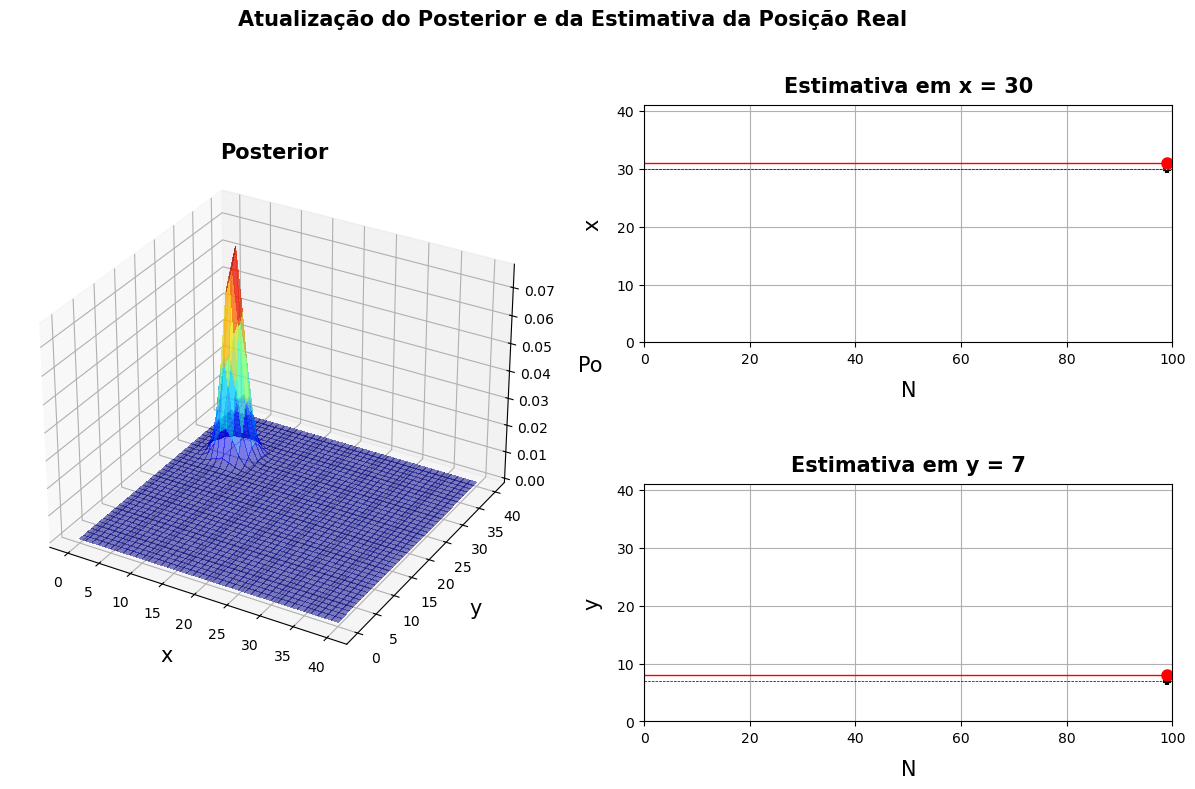

A posição real é x=[31] e y=[8]
A posição final estimada é x=[30] e y=[7]


In [4]:
# Loop principal (Bayes iterativo)

# Recupera os índices "a" e "b" que indicam que Po está em seu máximo
# (é a melhor estimativa para a posição da codorna!)
[a, b] = np.where(Po == np.max(np.max(Po)))

# Utilizando "a" e "b" para dar o melhor chute inicial
sest = [a, b]
sest = np.asarray(sest)

# Define uma matriz de covariancia para construir a Gaussiana em 2 dimensões
# 4 é um valor arbitrário (para x e y): 
# quanto maior, maior será o erro da estimativa;
# quanto menor, menor será o erro da estimativa
#K = [[81,0], [0,81]]
K = [[np.power(std,2),0], [0,np.power(std,2)]]
K = np.asarray(K)

# Loop principal (aplica o filtro de Bayes recursivamente):
for n in np.arange(x.shape[1]):
    # Início
    # prior = posterior (ou seja, o chute inicial é posterior, que será atualizado a cada iteração)
    Pr = Po
    m = 0. * Pr

    # Estimativa da Verossimilhanca (parte principal do programa):
    # Toma cada posição (me), assume que esta é a posição real da codorna
    # e calcula a verossimilhanca dos dados x(:,n), assumindo um ruído
    # Gaussiano em 2 dimensões
    for i in np.arange(Pr.shape[1]):
        for j in np.arange(Pr.shape[1]):

            me = [Sa[i], Sb[j]]
            me = np.asarray(me)
            
            # Cálculo da verossimilhança
            det = np.linalg.det(K)
            inv = np.linalg.inv(K)
            norm = 1. / np.sqrt(np.power((2. * np.pi),2) * det)
            m[i,j] =  norm * np.exp(np.matmul(-(x[:,n] - me), np.matmul(inv, (x[:,n] - me) / 2.)))
            
            # Combina a verossimilhanca calculada com o prior (calculamos nossa posterior, 
            # mas ela ainda não é uma distribuição de probabilidades, pois precisa ser normalizada)
            m[i,j] = m[i,j] * Pr[i,j]  
    
    # Normaliza a distribuição para torná-la uma distribuição de probabilidades própria 
    # (calcula a função massa de probabilidades: veja na célula anterior como Pr e Po foram calculados)
    Po = m / np.sum(np.sum(m))
    
    # Plota as figuras com a atualização do Posterior e das Coordenadas x e y:
    fig2 = plt.figure(figsize=(15,8))
    fig2.suptitle("Atualização do Posterior e da Estimativa da Posição Real", fontweight="bold", size=15, y=1)
    
    grid2 = plt.GridSpec(2, 2, wspace=0.2, hspace=0.6)
    
    plot3d = fig2.add_subplot(grid2[0:,0], projection="3d")
    plt2d1 = fig2.add_subplot(grid2[0, 1])
    plt2d2 = fig2.add_subplot(grid2[1, 1])
    
    axes2 = fig2.get_axes()
        
    # Posterior
    surf = plot3d.plot_surface(X, Y, Po, cmap=cm.jet, alpha=0.5, rstride=1, cstride=1,
                           linewidth=0.5, edgecolor="none", antialiased=False)
    axes2[0].set_title("Posterior", fontweight="bold", size=15, y=1.05)
    axes2[0].set_xlabel("x", labelpad=10, size="15")
    axes2[0].set_ylabel("y", labelpad=10, size="15")
    axes2[0].set_zlabel("Po", labelpad=15, size="15")     
        
    [a, b] = np.where(Po == np.max(np.max(Po)))
    sest = [a, b]
    sest = np.asarray(sest) 
  
    # Coordenada em x
    plt2d1.scatter(n,sest[0], color="black", marker="+", linewidth=3, label="x")
    plt2d1.scatter(n,s[0], color="red", marker="o", linewidth=3)
    plt2d1.axhline(y=s[0], color="red", linewidth=1)
    axes2[1].set_title("Estimativa em x = %i" % sest[0], fontweight="bold", size=15, y=1.02)
    axes2[1].grid(True)
    axes2[1].set_xlabel("N", labelpad=10, size="15")
    axes2[1].set_ylabel("x", labelpad=10, size="15")
    axes2[1].set_xlim(0,N)
    axes2[1].set_ylim(0,L)
    if n == (x.shape[1]-1):   
        axes2[1].axhline(sest[0], color="black", linewidth=0.5, ls="dashed")
        
    # Coordenada em y
    plt2d2.scatter(n,sest[1], color="black", marker="+", linewidth=3, label="y")
    plt2d2.scatter(n,s[1], color="red", marker="o", linewidth=3)
    plt2d2.axhline(y=s[1], color="red", linewidth=1)
    axes2[2].set_title("Estimativa em y = %i" % sest[1], fontweight="bold", size=15, y=1.02)
    axes2[2].grid(True)
    axes2[2].set_xlabel("N", labelpad=10, size="15")
    axes2[2].set_ylabel("y", labelpad=10, size="15")
    axes2[2].set_xlim(0,N)
    axes2[2].set_ylim(0,L)
    if n == (x.shape[1]-1):   
        axes2[2].axhline(sest[1], color="black", linewidth=0.5, ls="dashed")
          
    clear_output(wait=True)
    time.sleep(0.1)
    
    plt.show()

print("A posição real é x=" + str(s[0]) + " e y=" + str(s[1]))
print("A posição final estimada é x=" + str(sest[0]) + " e y=" + str(sest[1]))

## Exercícios

__No primeiro gráfico, está sendo considerando um desvio padrão arbitrário. Experimente alterar o valor de "std" utilizando números inteiros entre 2 e 20 (eg., 2, 4, 6, 8, ..., 20).__

1. O que acontece com a dispersão das estimativas do ninja em relação à posição real? 

2. O que acontece com as estimativas da posição real para os valores de "std" testados?

3. A estimativa da posição real converge mais rápido para quais valores de "std"?

4. Experimente alterar a posição da codorna e verifique novamente as alterações no valor do desvio padrão.

## Referências

* KALNAY, E. (2002). Atmospheric Modeling, Data Assimilation and Predictability. Cambridge: Cambridge University Press. doi:10.1017/CBO9780511802270
* http://studentdavestutorials.weebly.com/recursive-bayesian-estimation-with-matlab-code.html